In [1]:
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy import units as u
import pandas as pd
import os
import requests
import zipfile
import numpy as np
import matplotlib.pyplot as plt

In [2]:
targets = Table.read("../data/main-stack-targets-261020.fits").to_pandas()

In [3]:
# download if it doesn't exist given url
url = "https://zenodo.org/records/19184178/files/paper_data20260323.zip"
if not os.path.exists("../data/paper_data20260323.zip"):
    print("Downloading data from Zenodo...")
    r = requests.get(url)
    with open("../data/paper_data20260323.zip", "wb") as f:
        f.write(r.content)
    print("Download complete.")

# now unzip the file
# with zipfile.ZipFile("../data/paper_data20260323.zip", "r") as zip_ref:
#     zip_ref.extractall("../data/")

In [4]:
desi_confirmed = Table.read(
    "../data/paper_data20260323/table1.fits", format="fits"
).to_pandas()
desi_candidates = Table.read(
    "../data/paper_data20260323/table2.fits", format="fits"
).to_pandas()

In [5]:
confirmed_coincidences = pd.merge(targets, desi_confirmed, on="TARGETID", how="inner")
print(confirmed_coincidences)

             TARGETID  TARGET_RA_x  TARGET_DEC_x       Z_x   HB_N_FLUX  \
0    2706026876895232   323.690610     -6.838830  0.064120   81.439239   
1    2706303013093376   242.170484      4.689386  0.040374   60.981173   
2   39627622908433377    58.319909     -6.708934  0.025394  200.941119   
3   39627657628877456   337.685697     -5.517921  0.028254  386.686349   
4   39627685328066035   193.262140     -4.288302  0.009466  245.904992   
5   39627685395169704   197.041353     -4.350199  0.013170   59.117949   
6   39627687643318936   331.354567     -4.285806  0.009697  221.666503   
7   39627745398883762   175.815730     -1.651681  0.144538   92.649293   
8   39627757256184267   162.702631     -1.238850  0.025649  237.651684   
9   39627853687427435   150.439479      2.691775  0.219191   54.179908   
10  39627865620220315   141.806676      3.240268  0.005428  338.711241   
11  39627886759516057   323.667728      4.038503  0.014514  164.720235   

    HB_N_FLUX_ERR  OIII5007_FLUX  OII

In [6]:
candidate_coincidences = pd.merge(targets, desi_candidates, on="TARGETID", how="inner")
print(candidate_coincidences)

            TARGETID  TARGET_RA_x  TARGET_DEC_x       Z_x   HB_N_FLUX  \
0  39627818174254064   193.669122      1.323864  0.081629   59.817394   
1  39627849056916629   234.443731      2.573811  0.006162  157.445512   

   HB_N_FLUX_ERR  OIII5007_FLUX  OIII5007_FLUX_ERR  NII6583_FLUX  \
0       1.026806     194.303095           2.187074      1.831656   
1       3.226055     319.660889          50.255626      6.692548   

   NII6583_FLUX_ERR  ...       E_DEN   E_DEN_ERR    OIII_E_TEM  \
0          0.671784  ...  404.036804  587.184326  17310.935547   
1          1.454011  ...  100.000000    0.000000  18024.404297   

   OIII_E_TEM_ERR  O_ABUNDANCE  O_ABUNDANCEERR      mass  mass_err    logSFR  \
0     2795.055664     7.564737        0.174875  8.221128  0.229393 -0.181654   
1     2938.179443     7.539527        0.166335  6.912047  0.215680 -1.843716   

   logSFR_ERR  
0    0.133510  
1    0.130617  

[2 rows x 68 columns]


In [7]:
confirmed_coincidences[
    [
        "TARGETID",
        "O_ABUNDANCE",
        "oiii4363_snr",
        "oii7320_snr",
        "oii7330_snr",
    ]
]

,TARGETID,O_ABUNDANCE,oiii4363_snr,oii7320_snr,oii7330_snr
0,2706026876895232,7.529716,6.831558,3.717283e-33,3.422368e+00
1,2706303013093376,7.126259,5.912431,1.999660e+00,1.229683e+00
2,39627622908433377,7.438375,4.247629,5.105190e+00,3.672443e+00
3,39627657628877456,7.469346,7.853418,4.361829e+00,3.281691e+00
4,39627685328066035,7.209697,5.935950,2.215942e+00,2.040822e+00
5,39627685395169704,7.408575,5.061106,1.986185e+00,3.340989e+00
6,39627687643318936,7.478679,5.944640,3.217093e+00,2.283677e+00
7,39627745398883762,7.318763,8.895018,3.908074e+00,3.498340e+00
8,39627757256184267,7.541931,7.974326,5.069399e+00,3.243435e+00
9,39627853687427435,7.150377,12.664609,2.223491e-05,3.535241e-34


In [8]:
np.sum(desi_confirmed["O_ABUNDANCE"] < 7.25)

37

In [9]:
np.sum(desi_candidates["O_ABUNDANCE"] < 7.3)

0

(array([ 2.,  0.,  5.,  2.,  6.,  8.,  9.,  8., 23., 24., 30., 39., 42.,
        71., 67., 89., 95., 84., 44., 14.]),
 array([6.98613501, 7.01952362, 7.05291271, 7.0863018 , 7.11969042,
        7.15307903, 7.18646812, 7.21985722, 7.25324583, 7.28663445,
        7.32002354, 7.35341263, 7.38680124, 7.42018986, 7.45357895,
        7.48696804, 7.52035666, 7.55374527, 7.58713436, 7.62052345,
        7.65391207]),
 <BarContainer object of 20 artists>)

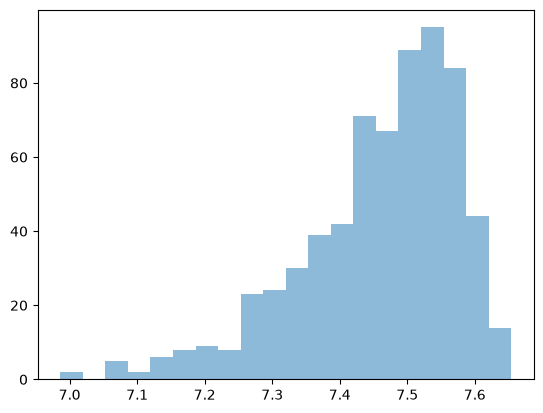

In [10]:
plt.hist(desi_confirmed["O_ABUNDANCE"], bins=20, alpha=0.5, label="Confirmed")

In [11]:
desi_confirmed.query("O_ABUNDANCE < 7.25 and Z<0.27")[["Z"]]

,Z
0,0.002596
1,0.150690
2,0.015377
3,0.017379
4,0.012039
7,0.038942
8,0.054257
9,0.040374
10,0.024214
11,0.122515


In [12]:
targets.columns

Index(['TARGETID', 'TARGET_RA', 'TARGET_DEC', 'Z', 'HB_N_FLUX',
       'HB_N_FLUX_ERR', 'OIII5007_FLUX', 'OIII5007_FLUX_ERR', 'NII6583_FLUX',
       'NII6583_FLUX_ERR', 'HA_N_FLUX', 'HA_N_FLUX_ERR', 'R3', 'NII_detected',
       'N2', 'N2_uplim', 'N2_distilled', 'input_z', 'z_ha_n2', 'zerr_ha_n2',
       'flux_nii6549', 'fluxerr_nii6549', 'flux_ha', 'fluxerr_ha',
       'flux_nii6585', 'fluxerr_nii6585', 'z_hb', 'zerr_hb', 'flux_hb',
       'fluxerr_hb', 'z_o3_b', 'zerr_o3_b', 'flux_o3_b', 'fluxerr_o3_b',
       'status', 'error', 'vg_r3', 'vg_n2_detected', 'vg_n2_undetected',
       'vg_n2_distilled', 'oiii4363_flux', 'oiii4363_flux_err', 'oiii4363_snr',
       'oii7320_flux', 'oii7320_flux_err', 'oii7320_snr', 'oii7330_flux',
       'oii7330_flux_err', 'oii7330_snr'],
      dtype='object')

(array([ 1.,  0.,  0.,  1.,  2.,  6., 10., 15., 13.,  5.]),
 array([-15.71261671, -15.43636062, -15.16010452, -14.88384843,
        -14.60759233, -14.33133624, -14.05508014, -13.77882405,
        -13.50256795, -13.22631186, -12.95005576]),
 <BarContainer object of 10 artists>)

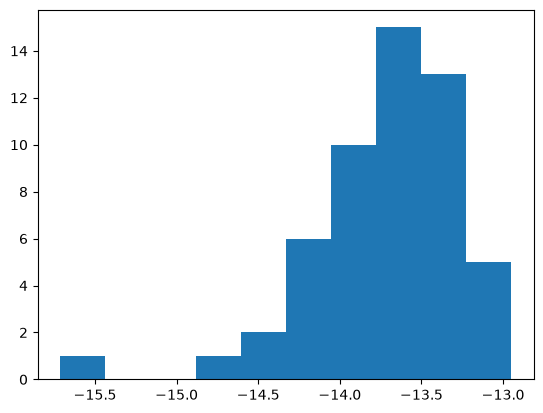

In [13]:
plt.hist(np.log10(targets["flux_o3_b"]) - 16)

In [14]:
non_dups = targets[~targets["TARGETID"].isin(desi_confirmed["TARGETID"])].copy()


(array([ 1.,  0.,  0.,  1.,  1.,  3., 11., 11.,  8.,  5.]),
 array([-15.71261671, -15.44810469, -15.18359267, -14.91908065,
        -14.65456862, -14.3900566 , -14.12554458, -13.86103255,
        -13.59652053, -13.33200851, -13.06749648]),
 <BarContainer object of 10 artists>)

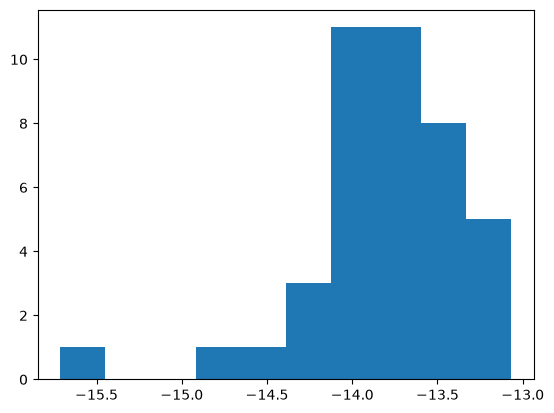

In [15]:
plt.hist(np.log10(non_dups["flux_o3_b"]) - 16)

In [18]:
brightest = non_dups.sort_values(by="flux_o3_b", ascending=False).iloc[:30].copy()

(array([4., 2., 3., 6., 4., 3., 1., 5., 1., 1.]),
 array([-14.03996119, -13.94271472, -13.84546825, -13.74822178,
        -13.65097531, -13.55372884, -13.45648237, -13.3592359 ,
        -13.26198943, -13.16474296, -13.06749648]),
 <BarContainer object of 10 artists>)

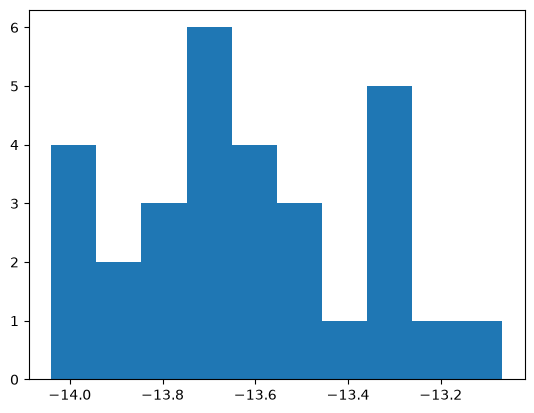

In [19]:
plt.hist(np.log10(brightest["flux_o3_b"]) - 16)

In [20]:
brightest[["TARGETID", "TARGET_RA", "TARGET_DEC"]]

,TARGETID,TARGET_RA,TARGET_DEC
38,39627841343589611,134.670615,2.196797
26,39627757734333522,191.187236,-1.148542
1,2389515943542784,185.126127,-0.449030
50,39627945395885374,231.030221,6.435184
31,39627781927078884,193.140833,-0.167576
40,39627849056916629,234.443731,2.573811
49,39627926706061620,191.306882,5.872727
29,39627775753063070,185.126469,-0.450867
22,39627726738426677,143.644954,-2.532366
44,39627876009515081,41.991696,3.840302


In [21]:
import numpy as np
from dl import queryClient as qc


def get_r_magnitude(targetid):
    """
    Given a DESI DR1 TARGETID, return the R-band (Legacy Surveys) AB magnitude
    of the source.

    The R-band photometry is not part of any local DESI catalog in this
    project (the local FITS files only contain redshifts/line fluxes). It
    lives in the Legacy Surveys DR9 tractor photometry that DESI copies into
    each target's record, which is queryable through NOIRLab's Astro Data Lab
    remote database, table `desi_dr1.photometry` (columns TARGETID, FLUX_R,
    MW_TRANSMISSION_R). No account/login is needed for anonymous queries.

    Parameters
    ----------
    targetid : int
        The DESI TARGETID of the source.

    Returns
    -------
    r_mag : float
        The Milky-Way-extinction-corrected R-band AB magnitude, or np.nan if
        the source is not found or has non-positive flux.
    """
    result = qc.query(
        sql=f"SELECT flux_r, mw_transmission_r FROM desi_dr1.photometry "
        f"WHERE targetid = {int(targetid)}"
    )

    rows = [line for line in result.strip().splitlines()[1:] if line]
    if not rows:
        raise ValueError(f"TARGETID {targetid} not found in desi_dr1.photometry")

    flux_r, mw_transmission_r = (float(x) for x in rows[0].split(","))

    if mw_transmission_r > 0:
        flux_r = flux_r / mw_transmission_r

    if flux_r <= 0:
        return np.nan

    # DESI/Legacy Surveys fluxes are in nanomaggies
    r_mag = 22.5 - 2.5 * np.log10(flux_r)

    return r_mag


In [22]:
for targetid in brightest["TARGETID"]:
    print(targetid, get_r_magnitude(targetid))


39627841343589611 19.606067087916184
39627757734333522 19.583813005017866
2389515943542784 20.70777406414343
39627945395885374 19.6462345273759
39627781927078884 18.828265379921927
39627849056916629 17.805905838365952
39627926706061620 19.831692207392205
39627775753063070 17.67340141533659
39627726738426677 19.657335629578885
39627876009515081 18.997620118513737
39627884981128555 18.7906146124835
39627896234445067 19.321816291026636
39627848780090931 17.587117251674766
39627601517479958 19.699445326054125
39627974852480575 18.068061329031462
39627673546262944 19.298318076223712
39627763912544115 18.838126110612794
39627655498177307 20.313971172272282
39627708434484707 18.41575583098283
39627818174254064 19.626641436226162
39627838319496035 19.497050754220993
2706174780637184 20.44816569088751
39627832363582986 18.940097024281947
39627562309125549 21.62948675210685
39627799857730585 22.633164686374652
2706139288436736 19.344609005586243
2706107944402944 20.346095324981775
39627860868074

In [23]:
brightest["R_mag"] = np.nan
for targetid in brightest["TARGETID"]:
    # print(targetid, get_r_magnitude(targetid))
    brightest.loc[brightest["TARGETID"] == targetid, "R_mag"] = get_r_magnitude(
        targetid
    )

In [24]:
len(
    brightest.sort_values(by="R_mag", ascending=True)[
        ["TARGETID", "flux_o3_b", "R_mag"]
    ]
)

30

In [25]:
non_dups["R_mag"] = np.nan
for targetid in non_dups["TARGETID"]:
    non_dups.loc[non_dups["TARGETID"] == targetid, "R_mag"] = get_r_magnitude(targetid)

In [26]:
brightest = non_dups[non_dups["R_mag"] < 21].copy()

In [27]:
brightest = brightest.sort_values(by="R_mag", ascending=True).copy()

In [28]:
brightest[["TARGETID", "R_mag", "flux_o3_b"]]

,TARGETID,R_mag,flux_o3_b
39,39627848780090931,17.587117,264.643061
29,39627775753063070,17.673401,373.077856
40,39627849056916629,17.805906,443.705011
51,39627974852480575,18.068061,230.226819
21,39627708434484707,18.415756,191.930140
45,39627884981128555,18.790615,333.100059
31,39627781927078884,18.828265,497.417667
27,39627763912544115,18.838126,210.229140
36,39627832363582986,18.940097,160.740123
44,39627876009515081,18.997620,344.709581


In [29]:
final_sample = pd.DataFrame({"Name": brightest["TARGETID"]})

In [30]:
brightest.apply(
    lambda row: f"log(oiii5007)={np.log10(row['flux_o3_b']) - 16:.1f}", axis=1
)

39    log(oiii5007)=-13.6
29    log(oiii5007)=-13.4
40    log(oiii5007)=-13.4
51    log(oiii5007)=-13.6
21    log(oiii5007)=-13.7
45    log(oiii5007)=-13.5
31    log(oiii5007)=-13.3
27    log(oiii5007)=-13.7
36    log(oiii5007)=-13.8
44    log(oiii5007)=-13.5
16    log(oiii5007)=-13.7
47    log(oiii5007)=-13.6
4     log(oiii5007)=-13.9
37    log(oiii5007)=-13.7
26    log(oiii5007)=-13.3
38    log(oiii5007)=-13.1
35    log(oiii5007)=-13.7
50    log(oiii5007)=-13.3
22    log(oiii5007)=-13.5
11    log(oiii5007)=-13.6
49    log(oiii5007)=-13.4
6     log(oiii5007)=-14.0
7     log(oiii5007)=-14.0
13    log(oiii5007)=-13.7
3     log(oiii5007)=-13.9
42    log(oiii5007)=-14.0
5     log(oiii5007)=-13.8
1     log(oiii5007)=-13.3
9     log(oiii5007)=-14.1
dtype: object

In [31]:
coords = SkyCoord(ra=brightest["TARGET_RA"].values * u.deg, dec=brightest["TARGET_DEC"].values * u.deg, frame="icrs")
print(coords.ra.to_string(unit=u.hour, sep=":", precision=2, pad=True))
coords.dec.to_string(unit=u.deg, sep=":", precision=2, pad=True)

['14:31:37.50' '12:20:30.35' '15:37:46.50' '13:14:20.42' '08:49:17.25'
 '14:29:44.53' '12:52:33.80' '13:17:41.91' '21:17:08.29' '02:47:58.01'
 '13:56:47.67' '11:17:29.16' '13:16:23.17' '20:57:20.46' '12:44:44.94'
 '08:58:40.95' '12:54:40.59' '15:24:07.25' '09:34:34.79' '14:16:34.31'
 '12:45:13.65' '14:01:33.00' '09:50:16.05' '14:01:30.24' '08:42:14.79'
 '14:33:34.73' '10:18:48.67' '12:20:30.27' '11:00:59.63']


array(['02:24:42.50', '-00:27:03.12', '02:34:25.72', '07:46:35.07',
       '-03:10:02.17', '04:06:50.37', '-00:10:03.27', '-01:00:02.01',
       '01:48:13.65', '03:50:25.09', '-04:41:14.83', '04:36:41.76',
       '-02:00:49.74', '02:06:33.91', '-01:08:54.75', '02:11:48.47',
       '01:19:25.91', '06:26:06.66', '-02:31:56.52', '-07:37:44.40',
       '05:52:21.82', '00:16:55.21', '00:54:06.86', '-05:36:01.31',
       '-03:11:55.21', '02:57:07.74', '-00:23:52.40', '-00:26:56.51',
       '01:56:43.21'], dtype='<U12')

In [32]:
brightest["Z"].round(3).max()

0.082

In [33]:
final_sample["RA"] = coords.ra.to_string(unit=u.hour, sep=":", precision=2, pad=True)
final_sample["Dec"] = coords.dec.to_string(unit=u.deg, sep=":", precision=2, pad=True)
final_sample["Mag"] = brightest.apply(lambda row: f"(R={row['R_mag']:.2f})", axis=1)
final_sample["z"] = brightest["Z"].round(3)
final_sample["Comment"] = brightest.apply(
    lambda row: (
        f"log(oiii5007)={np.log10(row['flux_o3_b']) - 16:.1f}"
    ),
    axis=1,
)

In [34]:
final_sample.to_csv("../data/final_sample.csv", index=False)

(array([2., 4., 2., 5., 4., 2., 3., 4., 2., 1.]),
 array([-14.06483071, -13.96509729, -13.86536386, -13.76563044,
        -13.66589702, -13.5661636 , -13.46643017, -13.36669675,
        -13.26696333, -13.16722991, -13.06749648]),
 <BarContainer object of 10 artists>)

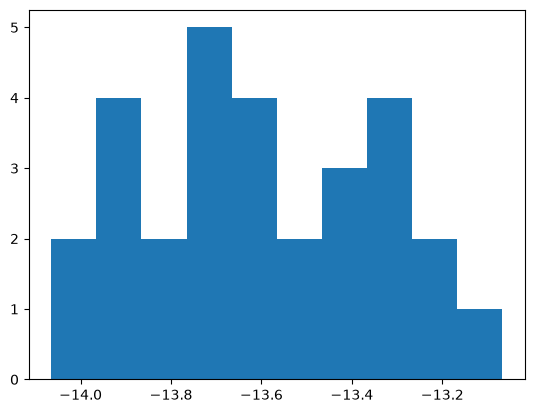

In [35]:
plt.hist(np.log10(brightest["flux_o3_b"]) - 16)